# 14. Self-counterfactual defense без парного clean

## Откуда мы пришли

1. Успех атаки определяем только для заранее выбранного clean-target: скрыт ли тот же человек после патча при `confidence >= 0.25` и `IoU >= 0.5`.
2. Простые гипотезы «патч недостаточно распространился» и «распространился не в важные нейроны» не объяснили детектор: важен ансамбль конкурирующих кандидатов и нелинейная маршрутизация через score, geometry и NMS.
3. Oracle-эксперимент с парой clean/patched нашёл joint score+geometry functional component: в среднем около 0.29% полной feature-delta. Её удаление восстановило 193/193 скрытых целей. Обратный перенос одной компоненты воспроизвёл лишь 97/193 атак: для достаточности нужен окружающий нелинейный контекст.
4. Здесь clean-пара недоступна методу. Из единственного наблюдаемого изображения строятся три self-counterfactual вида области патча (`gray`, `context_mean`, `blur`). Максимальный согласованный прирост person-score задаёт псевдо-target и proxy→observed delta. Из неё извлекается малая joint score+geometry компонента.
5. Порог включения защиты калибруется только на отдельной половине чистых изображений. Attack labels и paired clean не участвуют в выборе порога.

**Граница постановки.** Это no-paired-clean gray-box: известна область патча и доступны Detect-input activations/gradients. Это ещё не blind localization и не output-only black box. Paired clean используется ниже исключительно как скрытая разметка для оценки target recovery и полного набора детекций.

Ноутбук ничего тяжёлого не считает: он читает готовые CSV и строит графики почти мгновенно.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')
ROOT = Path.cwd()
if ROOT.name != 'CandidateRoutingAndAttackPath':
    ROOT = ROOT / 'CandidateRoutingAndAttackPath'
runs = []
for d in sorted((ROOT / 'followup_outputs').glob('self_counterfactual_*')):
    p = d / 'summary.json'
    if not p.exists():
        continue
    summary = json.loads(p.read_text())
    rows = pd.read_csv(d / 'self_counterfactual_rows.csv')
    runs.append({'dir': d, 'summary': summary, 'rows': rows,
                 'strength': summary['config'].get('proxy_strength', 1.0)})
full_candidates = [r for r in runs if r['strength'] == 1.0 and 'observed_detection_f1' in r['rows']]
weak_candidates = [r for r in runs if r['strength'] == 0.5]
full = max(full_candidates, key=lambda r: r['summary']['config'].get('method_version', 0))
weak = max(weak_candidates, key=lambda r: r['summary']['config'].get('method_version', 0))
F, W = full['rows'], weak['rows']
print('full:', full['dir'].name, '| weak:', weak['dir'].name)
print('Disk footprint:', sum(p.stat().st_size for p in (ROOT/'followup_outputs').rglob('*') if p.is_file()) / 2**20, 'MiB')

full: self_counterfactual_ceeb0759892c167f | weak: self_counterfactual_bfde7b2d6e36bf36
Disk footprint: 26.906487464904785 MiB


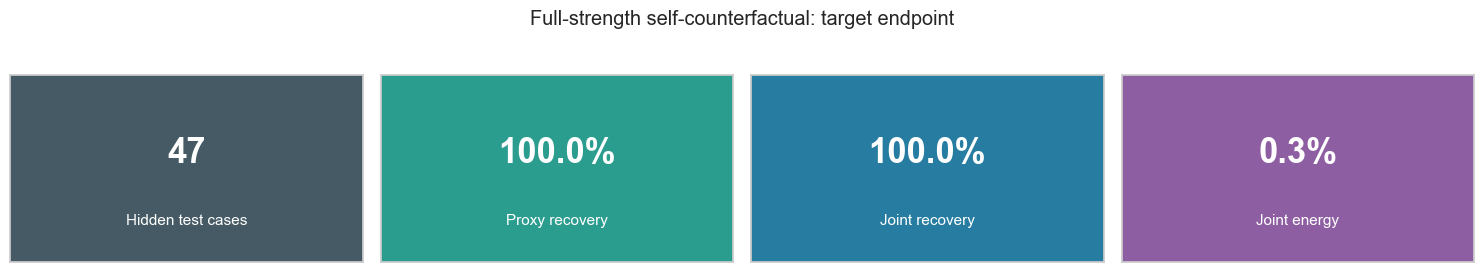

In [2]:
hidden = F[(F.input_kind == 'patched') & (F.source_hidden == 1)]
clean_test = F[(F.input_kind == 'clean') & (F.clean_split == 'test')]
gate = pd.read_csv(full['dir'] / 'gate_decisions.csv')
g_clean = gate[(gate.input_kind == 'clean') & (gate.clean_split == 'test')]
g_hidden = gate[(gate.input_kind == 'patched') & (gate.source_hidden == 1)]
cards = [
    ('Hidden test cases', len(hidden), '#455a64'),
    ('Proxy recovery', hidden.proxy_view_target_detected.mean(), '#2a9d8f'),
    ('Joint recovery', hidden.joint_repair_target_detected.mean(), '#277da1'),
    ('Joint energy', hidden.joint_energy_fraction.mean(), '#8e5ea2'),
]
fig, axes = plt.subplots(1, 4, figsize=(15, 2.6))
for ax, (label, value, color) in zip(axes, cards):
    ax.set_facecolor(color)
    shown = f'{value:.1%}' if isinstance(value, (float, np.floating)) else str(value)
    ax.text(.5, .58, shown, ha='center', va='center', fontsize=25, color='white', weight='bold')
    ax.text(.5, .22, label, ha='center', va='center', fontsize=11, color='white')
    ax.set(xticks=[], yticks=[])
plt.suptitle('Full-strength self-counterfactual: target endpoint', y=1.04)
plt.tight_layout()
plt.show()

**Что видно.** При полной замене известной области патча proxy и target-only joint correction восстанавливают все 47/47 исходно скрытых целей. Но это ещё не доказательство полезности малой компоненты: сама proxy-маскировка уже даёт 47/47, поэтому коррекция пока не добавляет target-recovery поверх простого удаления содержимого patch box. Средняя энергия joint-компоненты мала, но её безопасность нельзя выводить из одной энергии — это проверяется ниже на всех детекциях.

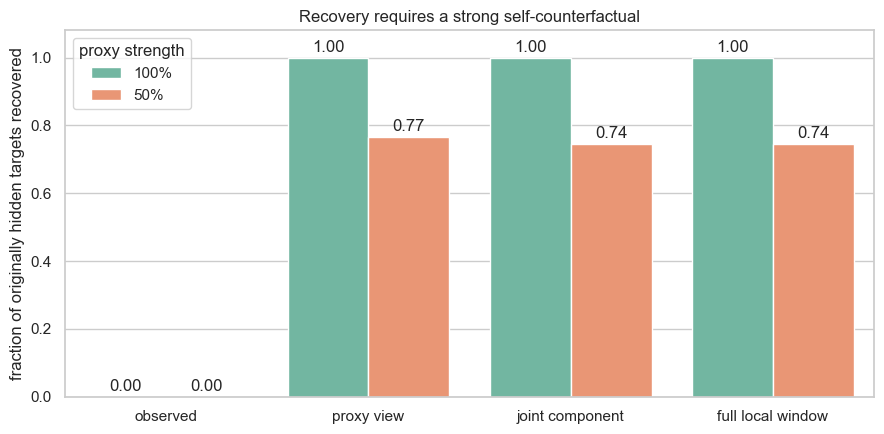

joint correction succeeds,False,True
weak proxy succeeds,,
False,10,1
True,2,34


In [3]:
def endpoint_table(rows, label):
    h = rows[(rows.input_kind == 'patched') & (rows.source_hidden == 1)]
    return pd.DataFrame({
        'proxy strength': label,
        'method': ['observed', 'proxy view', 'joint component', 'full local window'],
        'target recovery': [h.observed_target_detected.mean(), h.proxy_view_target_detected.mean(),
                            h.joint_repair_target_detected.mean(), h.full_window_repair_target_detected.mean()]
    })
recovery = pd.concat([endpoint_table(F, '100%'), endpoint_table(W, '50%')])
plt.figure(figsize=(9, 4.5))
ax = sns.barplot(data=recovery, x='method', y='target recovery', hue='proxy strength', palette='Set2')
ax.set_ylim(0, 1.08); ax.set_ylabel('fraction of originally hidden targets recovered'); ax.set_xlabel('')
for c in ax.containers: ax.bar_label(c, fmt='%.2f', padding=2)
plt.title('Recovery requires a strong self-counterfactual')
plt.tight_layout(); plt.show()

wh = W[(W.input_kind == 'patched') & (W.source_hidden == 1)]
display(pd.crosstab(wh.proxy_view_target_detected.astype(bool), wh.joint_repair_target_detected.astype(bool),
                    rownames=['weak proxy succeeds'], colnames=['joint correction succeeds']))

**Что видно.** При 50%-й замене proxy восстанавливает 36/47 целей, joint correction — 35/47. В 11 случаях три слабых counterfactual-вида вообще не согласуются на псевдо-target. В таблице есть единичные расхождения в обе стороны, но систематического выигрыша проекции нет. Значит, главный bottleneck сейчас — не точность извлечения компоненты, а построение достаточно информативного proxy без clean.

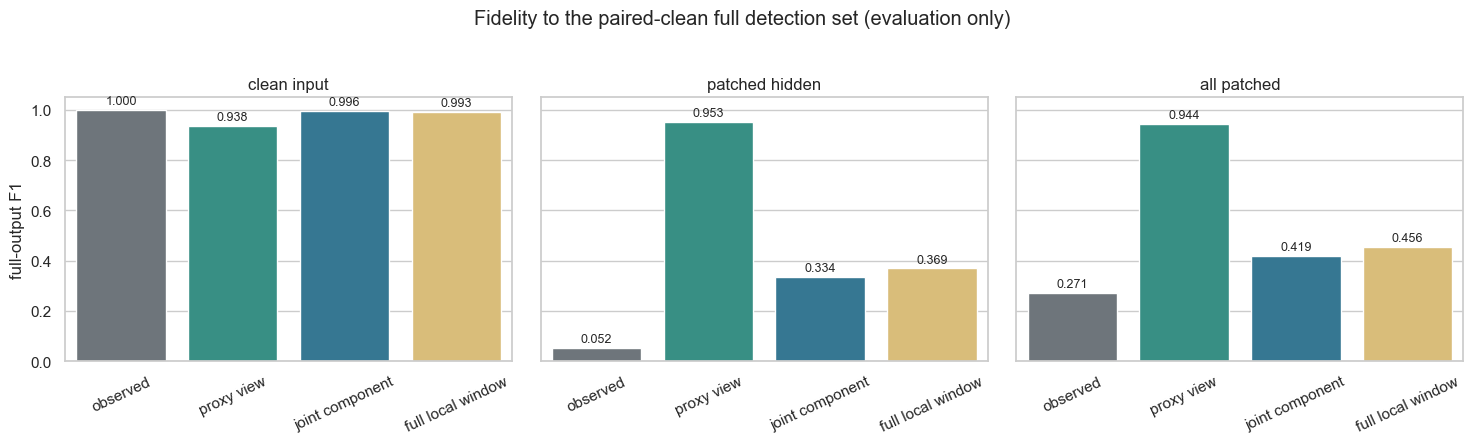

input,all patched,clean input,patched hidden
method,,,
full local window,0.4560,0.9931,0.3695
joint component,0.4187,0.9962,0.3338
observed,0.2712,1.0000,0.0522
proxy view,0.9445,0.9379,0.9525


In [4]:
conditions = {
    'observed': 'observed_detection_f1',
    'proxy view': 'proxy_view_detection_f1',
    'joint component': 'joint_repair_detection_f1',
    'full local window': 'full_window_repair_detection_f1',
}
parts = []
for subset_name, sub in [('clean input', F[F.input_kind == 'clean']),
                         ('patched hidden', hidden),
                         ('all patched', F[F.input_kind == 'patched'])]:
    for method, col in conditions.items():
        parts.append({'input': subset_name, 'method': method, 'full-output F1': sub[col].mean()})
fidelity = pd.DataFrame(parts)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), sharey=True)
for ax, subset_name in zip(axes, ['clean input', 'patched hidden', 'all patched']):
    q = fidelity[fidelity.input == subset_name]
    sns.barplot(data=q, x='method', y='full-output F1', hue='method', legend=False, ax=ax,
                palette=['#6c757d','#2a9d8f','#277da1','#e9c46a'])
    ax.set_title(subset_name); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=25); ax.set_ylim(0,1.05)
    for c in ax.containers: ax.bar_label(c, fmt='%.3f', padding=2, fontsize=9)
plt.suptitle('Fidelity to the paired-clean full detection set (evaluation only)', y=1.03)
plt.tight_layout(); plt.show()
display(fidelity.pivot(index='method', columns='input', values='full-output F1').round(4))

**Главный результат.** На чистом входе ошибочно применённая joint correction почти ничего не ломает (`F1≈0.996`), тогда как полная маскировка области снижает F1 примерно до `0.938`. Но на атакованных изображениях порядок меняется: proxy view почти восстанавливает полный clean output (`F1≈0.944` на всех patched и `≈0.953` на hidden), а target-only joint correction достигает лишь `≈0.419` и `≈0.334`. Она чинит выбранного человека, но не восстанавливает остальные уничтоженные детекции и может менять другие candidates/classes. Следовательно, «малая feature-energy» не равна «малому влиянию на output»; найденное подпространство функционально мало только относительно одного target.

,gate,clean activation rate,hidden target recovery,patched joint F1,patched proxy F1
0,proxy_gain,0.06,1.0000,0.4187,0.8954
1,repair_gain,0.02,0.9787,0.4132,0.8302
2,conservative_gain,0.06,1.0000,0.4187,0.8961


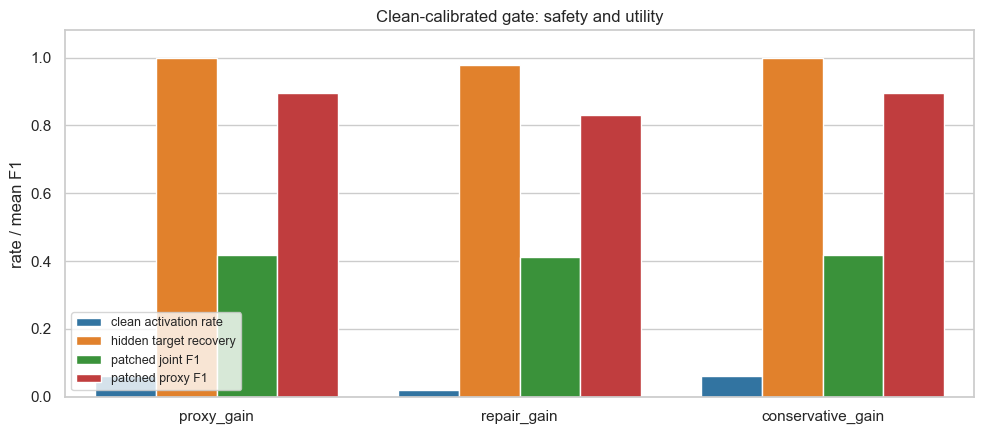

In [5]:
G = pd.read_csv(full['dir'] / 'gate_decisions.csv')
rows = []
for metric in ['proxy_gain', 'repair_gain', 'conservative_gain']:
    ct = G[(G.gate_metric == metric) & (G.input_kind == 'clean') & (G.clean_split == 'test')]
    ph = G[(G.gate_metric == metric) & (G.input_kind == 'patched') & (G.source_hidden == 1)]
    pa = G[(G.gate_metric == metric) & (G.input_kind == 'patched')]
    joint_f1 = np.where(pa.gate_applied.astype(bool), pa.joint_repair_detection_f1, pa.observed_detection_f1)
    proxy_f1 = np.where(pa.gate_applied.astype(bool), pa.proxy_view_detection_f1, pa.observed_detection_f1)
    rows.append({'gate': metric, 'clean activation rate': ct.gate_applied.astype(float).mean(),
                 'hidden target recovery': ph.defended_target_detected.mean(),
                 'patched joint F1': joint_f1.mean(),
                 'patched proxy F1': proxy_f1.mean()})
gate_result = pd.DataFrame(rows)
display(gate_result.round(4))
plot = gate_result.melt('gate', var_name='metric', value_name='value')
plt.figure(figsize=(10, 4.5))
ax = sns.barplot(data=plot, x='gate', y='value', hue='metric', palette='tab10')
ax.set_ylim(0, 1.08); ax.set_ylabel('rate / mean F1'); ax.set_xlabel('')
plt.title('Clean-calibrated gate: safety and utility')
plt.legend(loc='lower left', fontsize=9); plt.tight_layout(); plt.show()

**Что видно.** Порог, выбранный на 50 calibration-clean изображениях, включается на 0–6% из 50 независимых clean-test — оценка пока слишком мала для заявления о низком false-positive rate. Conservative gate сохраняет 47/47 recovery, если за ним стоит joint correction; но gated proxy даёт намного более высокий full-output F1 на patched. В трёх ложных срабатываниях conservative gate joint correction была значительно безопаснее маскировки. Поэтому у двух вариантов complementary trade-off: proxy лучше восстанавливает атакованный output, target-only correction мягче при ошибочном включении.

## Вывод и следующий причинный эксперимент

Текущая защита ещё не готова: она знает patch box, full-strength proxy фактически является сильной маскировкой, а clean calibration/test содержат лишь по 50 изображений. Тем не менее эксперимент дал конструктивный отрицательный результат: **target-only функциональная компонента достаточна для target recovery, но недостаточна для восстановления детектора как системы**.

Следующий тест — **global proxy-functional repair**:

- proxy по-прежнему строится без paired clean;
- вместо Jacobian только target reserve собираем строки score+geometry для всех устойчивых proxy-кандидатов всех классов;
- проектируем proxy→observed delta в объединённое функциональное подпространство и удаляем эту минимальную компоненту;
- сравниваем при одинаковой разметке: target recovery, full-output F1, clean false-positive harm и долю энергии;
- обязательные baselines: untouched, full proxy masking, текущая target-only correction и full local-window replacement.

Критерий успеха следующего шага: приблизиться к full-output F1 proxy-маскировки на attacked, сохранив clean-input F1 текущей малой коррекции. После этого отдельно убираем знание bbox с помощью blind multi-window consistency scan; смешивать эти две неизвестные в одном эксперименте сейчас не стоит.